# Python packages installation

A good [introduction](https://github.com/astrofrog/py4sci) to Python in [Jupyter Notebooks](http://jupyter.kip.uni-heidelberg.de/) is recommended for students that are new to using Python for data acquisition and analysis.

We are using the [JupyterLab](https://jupyter.org/) server with the [SciPy Notebook](https://hub.docker.com/r/jupyter/scipy-notebook) that is available for free and can be used on any computer.

First we install all additional Python packages required for this experiment with pip.

In [1]:
!pip3 install pyvisa-py pyserial pyusb zeroconf

# Communication with hardware


**Important:** All devices have to be enabled _prior_ to starting the JupyterLab server. If communication with hardware fails, shut down the server, enable _all_ devices, then start the JupyterLab server again.

## **PyVISA** library

**V**irtual **I**nstrument **S**oftware **A**rchitecture ([VISA](https://en.wikipedia.org/wiki/Virtual_instrument_software_architecture)) is a widely used application programming interface (API) in the test and measurement (T&M) industry for communicating with instruments from a computer.

* [PyVISA](https://pyvisa.readthedocs.io/en/latest/) is a Python package that allows to control all kinds of measurement devices independently of the interface (e.g. GPIB, RS232, USB, Ethernet).

* [PyVISA-py](https://pyvisa.readthedocs.io/projects/pyvisa-py/en/latest/) is a backend for **PyVISA**. It implements most of the methods for Message Based communication (Serial, USB, GPIB, Ethernet) using Python and some well developed, easy to deploy and cross platform libraries.

After importing the **PyVISA** library via ``import pyvisa`` the **PyVISA-py** backend can be used by choosing ``@py`` when instantiating the visa Resource Manager. 

Invoking the ``list_resources()`` method provides all locally available resources. 

## **USB** adapters for communication

The adapters have to be attached to the computer _and_ the devices enabled _before_ starting the JupyterLab Server, because the kernel module ``ftdi_sio`` will be reloaded with ``modprobe -r ftdi_sio ; modprobe ftdi_sio`` on starting the server and then probe the devices and configure their communication settings according to the devices attached. If communication does not work (due to devices not attached or enabled prior to starting the server) restarting the JupyterLab Server (closing the terminal and starting it again) may fix the issue.

In Linux the devices with USB ID ``0403:6001`` will be used by the kernel driver ``ftdi_sio`` that creates device files at ``/dev/ttyUSB0`` ...  ``/dev/ttyUSB1`` etc. with the lowest free name available. 

When there are multiple devices, the udev system allows to distinguish (e.g. via attributes in ``udevadm info --attribute-walk --name=ttyUSB0``) and create a stable mapping with udev rules in ``/etc/udev/rules.d/`` to ensure that unique symlinks always point to the same devices, even in case they happen to end up with other device files:

<!---
 * The [US232R-100-BULK](https://ftdichip.com/wp-content/uploads/2023/07/DS_US232R-10_R-100-500.pdf) is a generic USB to serial (RS232) adapter manufactured by [FTDI](https://ftdichip.com/). The file ``99-ftdi.rules`` creates ``/dev/ttyUSBSerial`` with ``SUBSYSTEMS=="usb", ATTRS{idVendor}=="0403", ATTRS{idProduct}=="6001", ATTRS{manufacturer}=="FTDI", ATTRS{product}=="US232R", MODE="0666", SYMLINK+="ttyUSBSerial"`` which will be listed as ``ASRL/dev/ttyUSBSerial::INSTR`` by **PyVISA**. 
-->

* The [Prologix GPIB-USB controller](https://prologix.biz/downloads/PrologixGpibUsbManual-6.0.pdf) is a USB bridge to GPIB (IEEE-488) adapter manufactured by [Prologix ](https://prologix.biz/). The file ``99-prologix.rules`` creates ``/dev/ttyUSBGPIB`` with ``SUBSYSTEMS=="usb", ATTRS{idVendor}=="0403", ATTRS{idProduct}=="6001", ATTRS{manufacturer}=="Prologix", ATTRS{product}=="Prologix GPIB-USB Controller", MODE="0666", SYMLINK+="ttyUSBGPIB"`` which will be listed as ``ASRL/dev/ttyUSBSerial::INSTR`` by **PyVISA**.

In this setup we use the Prologix GPIB-USB controller as an USB bridge to GPIB devices such as the Synthesized Function Generator (GPIB Address 19) or the Lock-In Amplifier (GPIB Address 7).

<!--
In addition we can use the generic FTDI USB to serial adapter to communicate with RS232 ports, in this case we need to ensure correct crossover mapping between receive (RXD) and transmit (TXD) pins of the RS232 cable (RXD@adapter pin 2 connected with TXD@device pin 3) and (TXD@adapter pin 3 connected with RXD@device pin 2), e.g. a "cross-over" cable with two female 9-pin RS232 connectors.
-->


In [2]:
import pyvisa # hardware access

rm = pyvisa.ResourceManager('@py') # choosing the PyVISA-py backend
print(rm.list_resources())         # list local hardware resources

('ASRL/dev/ttyUSBGPIB::INSTR',)


## **Prologix GPIB-USB** controller

The [Prologix GPIB-USB controller](https://prologix.biz/downloads/PrologixGpibUsbManual-6.0.pdf) converts any computer with a USB port into a **G**eneral **P**urpose **I**nterface **B**us ([GPIB](https://en.wikipedia.org/wiki/IEEE-488)) Controller or Device.

We use the Prologix GPIB-USB controller as an USB bridge to GPIB, it apppears as [FTDI](https://ftdichip.com/) FT232 (UART IC USB bridge with USB ID ``0403:6001``) as serial device ``/dev/ttyUSBGPIB`` in Linux and can be accessed as ``ASRL/dev/ttyUSBGPIB::INSTR`` in **PyVISA**.

Querying the resource with ``++ver`` asks the controller for its version, it will respond with its firmware version string.

In [3]:
import pyvisa # hardware access

rm  = pyvisa.ResourceManager('@py')                  # choosing the PyVISA-py backend
res = rm.open_resource('ASRL/dev/ttyUSBGPIB::INSTR') # open Prologix GPIB-USB controller
print(res.query("++ver"))                            # Query Prologix GPIB-USB controller for its firmware version

Prologix GPIB-USB Controller version 6.107



The Prologix GPIB-USB controller interprets high level commands received from the host computer and performs the appropriate low-level GPIB protocol
handshaking.

* In **Device mode** (``++mode 0``), Prologix GPIB-USB controller converts the computer into a GPIB peripheral for downloading data and screen plots from the instrument front panel. 

* In **Controller mode** (``++mode 1``), Prologix GPIB-USB controller can remotely control GPIB enabled instruments such as Oscilloscopes, Logic Analyzers, and Spectrum Analyzers.

In our case we will use the Prologix GPIB-USB controller in controller mode with ``++mode 1`` and choose to talk to the GPIB device at address 19 via ``++addr 19``.

All commands to the controller have a prefix of ``++`` while the everything else will be written on GPIB to the device address. 

The chars ESC (``x1b``), CR (``x0d``), LF (``x0a``) and PLUS (``x1b``) have to be escaped by an ESC (``x1b``) prefix.

In [4]:
import pyvisa # hardware access

rm  = pyvisa.ResourceManager('@py')                  # Choose the PyVISA-py backend
res = rm.open_resource('ASRL/dev/ttyUSBGPIB::INSTR') # Open Prologix GPIB-USB controller
res.write("++mode 1")                                # Put Prologix GPIB-USB in Controller-In-Charge (CIC) mode on the GPIB
res.write("++addr 19")                               # Choose device on GPIB address 19 for further communication
res.write("FREQ 123.456")                            # Write a command to this device on GPIB

14

## **Python classes**

We will use Python [classes](https://docs.python.org/3/tutorial/classes.html) to implement functionality in a hierarchy of sections that naturally divide a task into smaller sub-tasks that can be independently implemented and verified. 

Once a sub-task is finished the next sub-task can inherit the methods and attributes of the previous sub-task and this hierarchy can be expressed in individual Python classes.

The first argument in each method of a Python class is ```self``` referring to this instance of the Python class and can be used to to address attributes and methods of this instance.

In [5]:
class Base():                                                    # Class name
    def __init__(self, name="Default", purpose="communication"): # Constructor gets called when instance of class is created
        self.name = name                                         # Attribute of instance "self" called "name" will be set to value of variable "name"
        self.purpose = purpose                                   # Attribute set
        
    def help(self):
        print(f"Class {self.name} for {self.purpose}")


base = Base("GPIB", "hardware communication")                    # Instance of class created and constructor called with arguments. Inside the class the self reference is used for this
base.help()

Class GPIB for hardware communication


## **GPIB** class for Prologix GPIB-USB controller

A generic Python class for GPIB devices via the [Prologix GPIB-USB controller](https://prologix.biz/downloads/PrologixGpibUsbManual-6.0.pdf).

In [6]:
import pyvisa, re

ESCAPE_CHARS = ['\x1b', '\x0d', '\x0a', '\x2b'] # ESC, CR, LF, PLUS (ESC MUST BE FIRST)

def escape(data):
    # xlat_t = { ord(c):'\x1b' + c for c in '\x1b\r\n+' }; '+A\rB\nC\x1b'.translate(xlat_t)
    #==> '\x1b+A\x1b\rB\x1b\nC\x1b\x1b'
    for b in ESCAPE_CHARS:
        data = data.replace(b, '\x1b' + b) # prepend with ESC
    return data


class GPIB(Base): # Create class GPIB that interits the methods and attributes of the Base class
    """Use GPIB devices via Prologix GPIB-USB Controller Rev 6.4.1"""
    # https://pyvisa.readthedocs.io/en/latest/
    # https://prologix.biz/downloads/PrologixGpibUsbManual-6.0.pdf

    def __init__(self, dev="ttyUSBGPIB"):   # Constructor
        self.__parent = super(GPIB, self)                        # https://docs.python.org/3/library/functions.html#super
        self.__parent.__init__("GPIB", "hardware communication") # call constructor of parent class with arguments      
        self._rm   = pyvisa.ResourceManager("@py")               # using PyVISA-py
        self.setDev(dev)
        self._addr = None

    def setDev(self, dev):
        self._dev = str(dev)
        for res in sorted(self._rm.list_resources()):
            if self._dev in res:
                self._res = self._rm.open_resource(res)
                self.setRes(self._res)
        return self._dev
    
    def setRes(self, res):
        self._res = res
        self._res.read_termination  = "\n"
        self._res.write_termination = "\n"
        self._res.write("++mode 1") # "++mode" is "0" (GPIB TALKER or GPIB LISTENER) or "1" (Controller-In-Charge (CIC))
        return self._res

    def setAddr(self, addr):
        self._addr = int(addr)
        self._res.write("++addr " + str(self._addr))
        return self._addr
            
    def write(self, addr, data):
        self.setAddr(addr)
        return self._res.write(escape(data))

    def query(self, addr, data, dtype="float"):
        self.setAddr(addr)
        if dtype != "float":
            return self._res.query(data)
        return float(
            re.sub(
                '[^0-9eE\.+-]', '',
                self._res.query(escape(data))
            )
        )


## **SynFunGen** class for 30 MHz Synthesized Function Generator SRS DS345

A Python class for communication via GPIB with the 30 MHz Synthesized Function Generator (Stanford Research Systems Model [DS345](https://www.thinksrs.com/products/ds345.html)) inherits from the GPIB class.

In [7]:
# TODO for students: Implement a class SynFunGen that inherits from GPIB class and controls the function generator

from typing import Literal

class SynFunGen(GPIB):
    def __init__(self, addr=19):
        super().__init__()
        self.name = "SynFunGen"
        self.purpose = "controlling function generator"
        self.setAddr(addr)

    def write(self, var: Literal["FREQ", "AMPL"], val):
        return super().write(self._addr, f"{var} {val:.3f}")

    def query(self, var: Literal["FREQ", "AMPL"]):
        return super().query(self._addr, f"{var}?")


## **LockInAmp** class for Lock-In Amplifier SRS SR530

A Python class for communication via GPIB with the Lock-In Amplifier (Stanford Research Systems [SR530](https://www.thinksrs.com/products/sr510530.htm)) that inherits everything from the SynFunGen class (including its parent GPIB class, hence everything for implementation aswell).

In [8]:
# TODO for students: Implement a class LockInAmp that inherits from the function generator class and controls the Lock-In amplifier

class LockInAmp(GPIB):
    def __init__(self, inp_key="X2", out_key="X6", addr=7):
        super().__init__()
        self.name = "LockInAmp"
        self.purpose = "Bandpass and Amplifier"
        self.setAddr(addr)
        self.keys = {
            "in": inp_key,
            "out": out_key,
            "X": "QX",
            "Y": "QY"
        }

    def write(self, ch: Literal["in", "out"], val):
        return super().write(self._addr, f"{self.keys[ch]},{val:.3f}")

    def query(self, ch: Literal["X", "Y", "in", "out"]):
        return super().query(self._addr, f"{self.keys[ch]}")


## **DataWriter** class for writing data to files

A Python class for data storage into files. For numerical data using TSV or CSV format is suggested because of its widespread usage and software support.

We recommend the [Python CSV](https://docs.python.org/3/library/csv.html) library that provides a [DictWriter()](https://docs.python.org/3/library/csv.html#csv.DictWriter) method for data storage in CSV format.

In [9]:
# TODO for students: Implement a class DataWriter that inherits from the Lock-in amp class and
# provides methods to open a file name, write CSV headers and for each measurement a row of columns.

import csv

class DataWriter:
    def __init__(
        self,
        loc: str,
        cols: list[str],
        metadata: str | None = None
    ):
        self.cols = cols
        self.loc = loc
        self.metadata = str(metadata)
        self.write_metadata()
        self.write({key: key for key in self.cols})

    def write(self, row: dict):
        if not (self.cols == list(row.keys())):
            raise ValueError(f"Tried to write an invalid row: {row}.\nExpected keys: {self.cols}")
        with open(self.loc, 'a', newline='') as file:
            writer = csv.DictWriter(file, self.cols, delimiter=',')
            writer.writerow(row)

    def write_metadata(self):
        with open(self.loc, 'a', newline='') as file:
            file.write(self.metadata + "\n")

    def reset(self, confirm: bool):
        if not confirm:
            raise RuntimeError()
        with open(self.loc, 'w', newline='') as file:
            file.write("")
        self.write_metadata()
        self.write(self.cols)


## **Measurement** class for the measurement sequence

Now that we have every functionality ready (and individually tested!) we can finally implement the class that automates the measurement tasks according to the lab course manual.

Using [numpy](https://numpy.org/doc/stable/reference/index.html#reference) we recommend the methods [std()](https://numpy.org/doc/stable/reference/generated/numpy.std.html) and [mean()](https://numpy.org/doc/stable/reference/generated/numpy.mean.html) for calculating the mean value and standard deviation (repeated measurements under the same conditions).

For calculating the phase, we recommend the method [arctan2()](https://numpy.org/doc/stable/reference/generated/numpy.arctan2.html#numpy-arctan2) (described [here](https://en.wikipedia.org/wiki/Atan2) in detail).

In [10]:
SFG_CH = ["FREQ", "AMPL"]
LIA_CH = ["in", "out"]
LIA_CH_QUERY_ONLY = ["X", "Y"]

class Devices:
    def __init__(self):
        self.sfg = SynFunGen()
        self.lia = LockInAmp()

    def write(self, ch: str, val):
        if ch in SFG_CH:
            return self.sfg.write(ch, val)
        if ch in LIA_CH:
            return self.lia.write(ch, val)
        else:
            raise ValueError(f"Channel not valid: {ch}")

    def query(self, ch):
        if ch in SFG_CH:
            return self.sfg.query(ch)
        if ch in LIA_CH or ch in LIA_CH_QUERY_ONLY:
            return self.lia.query(ch)
        else:
            raise ValueError(f"Channel not valid: {ch}")

In [14]:
# TODO for students: Implement a class Measurement that inherits from the data writer class (and therefore everything else)
# for fully autonomous measurement sequences and data storage into individual files.

import numpy as np
from datetime import datetime
from time import sleep
from tqdm import tqdm

def calc_amplitude(x, y):
    return np.sqrt(x**2 + y**2)

def calc_phase_shift(x, y):
    return np.arctan2(y, x)


class ExperimentA:
    def __init__(
        self, 
        loc: str,
        freqs_series,
        trials: int = 20,
        sleeptime: float = 0.9,
        init_metadata: dict = dict()
    ):
        timestamp = datetime.now().strftime("%m%d_%H%M%S")
        self.loc = loc + "_" + timestamp + ".txt"
        self.freqs_series = freqs_series
        self.trials = trials
        self.sleeptime = sleeptime

        self.devices = Devices()

        self.init_metadata = init_metadata
        self.dw = DataWriter(self.loc, ["freq", "A", "A_std", "phi", "phi_std"], str(self.create_metadata()))

    def create_metadata(self) -> dict:
        return {"trials": self.trials, "sleeptime": self.sleeptime} | self.init_metadata
    
    def measure_A_phi(self):
        sleep(self.sleeptime)
        x = self.devices.query("X")
        y = self.devices.query("Y")
        return calc_amplitude(x, y), calc_phase_shift(x, y)
    
    def measure_at_freq(self, freq):
        self.devices.write("FREQ", freq)
        results = np.array([self.measure_A_phi() for _ in range(self.trials)])
        means = results.mean(axis=0)
        stds = results.std(axis=0) / np.sqrt(20)
        result = {"freq": freq, "A": means[0], "A_std": stds[0], "phi": means[1], "phi_std": stds[1]}
        self.dw.write(result)

    def execute(self):
        rt = self.sleeptime * len(self.freqs_series) * self.trials
        print(f"Starting Experiment with expected runtime: {rt} s.")
        for freq in tqdm(self.freqs_series):
            self.measure_at_freq(freq)


In [15]:
# len in meters
d = 200e-6
l = 0.02

# N / m**2
E = 98e9
# kg / m**3
rho = 8.5e3
v_upsilon = np.sqrt(E / rho)

ALPHA_N = [1.424987, 0.992249, 1.000198, 0.999994]

def get_alpha_n(n: int):
    if n > 3:
        return 1
    return ALPHA_N[n]

def calc_free_reed_eigenfrequency(n: int):
    alpha_n = get_alpha_n(n)
    nu = alpha_n * (2 * n + 1)**2 * np.pi * d * v_upsilon / (16 * np.sqrt(3) * l**2)
    return nu

target_freqs = [calc_free_reed_eigenfrequency(n) for n in range(4)]
print(target_freqs)
for i, freq in enumerate(target_freqs[1:]):
    print(f"nu_{i+1}/nu_0 = {freq / target_freqs[0]}")

target_freqs = target_freqs[:3]

[274.25448868690813, 1718.723524709954, 4812.478834467755, 9430.53467494007]
nu_1/nu_0 = 6.266892961128769
nu_2/nu_0 = 17.547493415729406
nu_3/nu_0 = 34.38607229399286


In [24]:
trials = 2
num = 2
pad = 3

locs = []

print(f"Analysing {len(target_freqs)} resonance peaks.")
for i, freq in enumerate(target_freqs):
    # if i != 1: continue
    loc = f"Data/Experiment_A/resonance{i}_data"
    # freqs_series = np.logspace(np.log10(freq) - padding, np.log10(freq) + padding, num=num)
    freqs_series = np.geomspace(freq - pad, freq + pad, num=num)
    expA = ExperimentA(loc, freqs_series, trials=trials, init_metadata={"target_freq": freq})
    
    expA.execute()
    locs.append(expA.loc)

Analysing 3 resonance peaks.
Starting Experiment with expected runtime: 3.6 s.


100%|██████████| 2/2 [00:03<00:00,  1.91s/it]


Starting Experiment with expected runtime: 3.6 s.


100%|██████████| 2/2 [00:03<00:00,  1.92s/it]


Starting Experiment with expected runtime: 3.6 s.


100%|██████████| 2/2 [00:03<00:00,  1.92s/it]


## **DataReader** class for reading data from files

A Python class for reading data from files. This class should implement reading from the data format we chose for holding our measurement data, hence the TSV or CSV format.

We recommend the [Python CSV](https://docs.python.org/3/library/csv.html) library that provides a [DictReader()](https://docs.python.org/3/library/csv.html#csv.DictReader) method for reading data from CSV files into Pyhton dictionaries.

For each value that is read as string from CSV a conversion to float can be done using the Python [float()](https://docs.python.org/3/library/functions.html#float) method with [exception](https://docs.python.org/3/tutorial/errors.html#handling-exceptions) handling.

## **DataPlot** class for plotting measurement data

A Python class for plotting measurement data. This class should implement a plotting routine suitable to display the measurement data.

We recommend combining [NumPy](https://numpy.org/) with the [MatPlotLib](https://matplotlib.org/) library that provides [plot()](https://matplotlib.org/stable/plot_types/basic/plot.html#sphx-glr-plot-types-basic-plot-py) and [errorbar()](https://matplotlib.org/stable/plot_types/stats/errorbar_plot.html#sphx-glr-plot-types-stats-errorbar-plot-py) functions.

For creating interactive plots that allow reading out values and zooming via mouse we suggest using the [ipympl](https://matplotlib.org/ipympl/) extension via ```%matplotlib ipympl``` in the cell prefix.

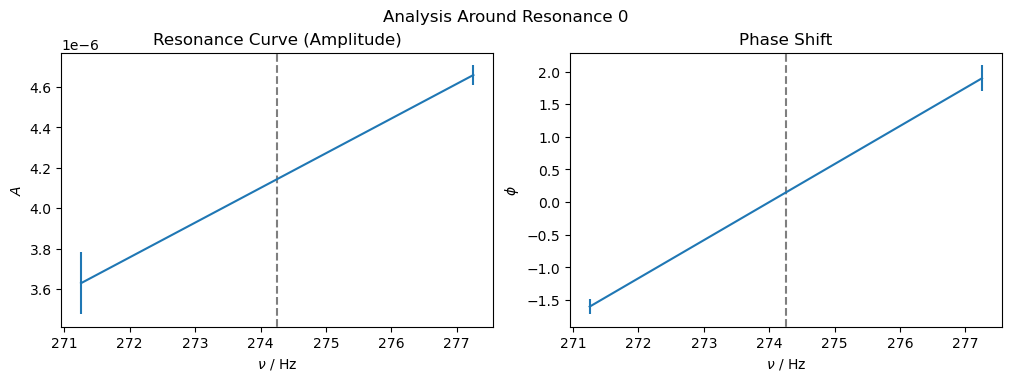

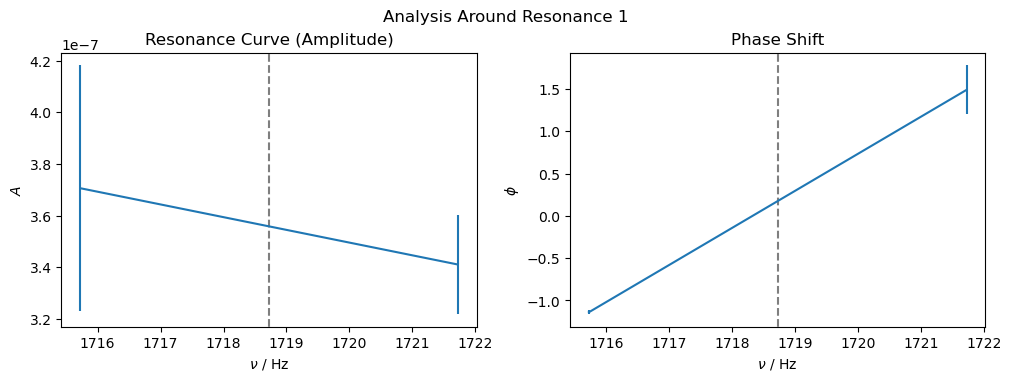

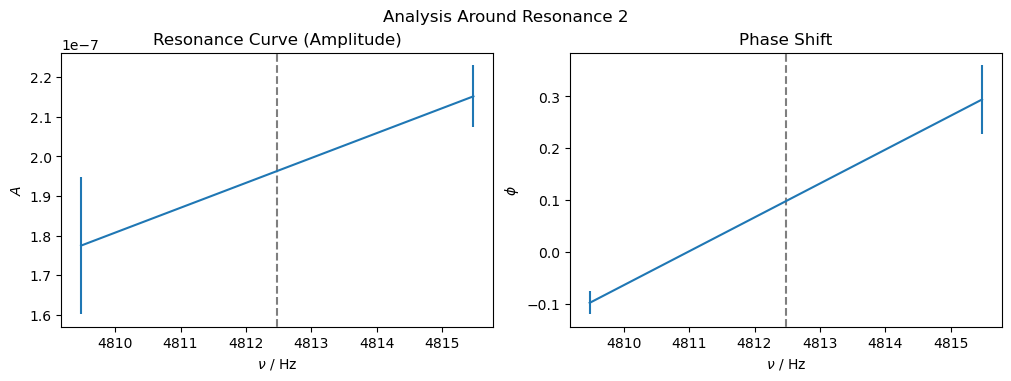

In [34]:
# TODO for students: Implement a class DataReader that does not need any inheritance from another class
# for reading back the measurement data into numerical (float) format.

# TODO for students: Implement a class DataPlot that plots the measurement data in interactive plots.

import matplotlib.pyplot as plt
import ast

def read_metadata(loc):
    with open(loc, "r") as file:
        return ast.literal_eval(file.readline())

def plot_target_freq(ax, target_freq: float):
    axes = ax.axis()
    ax.vlines(target_freq, -5, 5, colors="tab:grey", linestyles="--", label="Theoretical Peak")
    ax.axis(axes)

for i, loc in enumerate(locs):
    freq, A, A_err, phi, phi_err = np.loadtxt(
        loc,
        delimiter=",",
        skiprows=2,
        unpack=True
    )
    target_freq = read_metadata(loc)["target_freq"]
    
    freq_err = 0  
    
    fig, axs = plt.subplots(1, 2, figsize=(5*2, 3.7), constrained_layout=True)
    ax1, ax2 = axs
    ax1.errorbar(freq, A, yerr=A_err, xerr=freq_err)
    plot_target_freq(ax1, target_freq)
    ax1.set_xlabel(r"$\nu$ / Hz")
    ax1.set_ylabel(r"$A$")
    # ax1.set_xscale("log")
    ax1.set_title("Resonance Curve (Amplitude)")
    
    ax2.errorbar(freq, phi, yerr=phi_err, xerr=freq_err)
    plot_target_freq(ax2, target_freq)
    ax2.set_xlabel(r"$\nu$ / Hz")
    ax2.set_ylabel(r"$\phi$")
    ax2.set_title("Phase Shift")

    fig.suptitle(f"Analysis Around Resonance {i}")
    
    plt.show()


## **DataFit** class for fitting the measurement data

A Python class for fitting the measurement data. This class should implement an appropriate fit function that reflects the physics of the measurement data and allows extracting fit parameters.

We recommend using the method [curve_fit()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html) from the [SciPy](https://scipy.org/) library.

In [ ]:
# TODO for students: Implement a class DataFit that fits the measurement data in interactive plots.


